# 05 — Before / After Analysis

Compares the original trained YOLOv3 against the Tucker-2-compressed
version: parameter count, model size on disk, inference latency, and
detection accuracy (mAP@0.5) on the held-out validation subset.

In [1]:
import sys, os, json
sys.path.append(os.path.abspath("../src"))
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from model import YOLOv3, count_conv_params
from dataset import CocoSubsetDataset, yolo_collate_fn
from tucker_decompose import get_compressible_conv_layers, tucker2_factorize_conv, set_module_by_name
from postprocess import predict_boxes, simple_map50
from analysis_utils import count_params, model_size_mb, measure_latency

with open("../checkpoints/run_config.json") as f:
    cfg = json.load(f)
CLASS_NAMES, IMG_SIZE, DATA_ROOT, BATCH_SIZE = cfg["class_names"], cfg["img_size"], cfg["data_root"], cfg["batch_size"]
NUM_CLASSES = len(CLASS_NAMES)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

with open("../checkpoints/compression_log.json") as f:
    compression_log = json.load(f)

## Load both models

The compressed model has to be rebuilt with the same layer-by-layer
factorization before `load_state_dict` — the checkpoint stores the factored shapes.

In [2]:
original = YOLOv3(num_classes=NUM_CLASSES)
state = torch.load("../checkpoints/yolov3_best.pt", map_location="cpu")
original.load_state_dict(state["model_state"])
original.to(DEVICE).eval()

compressed = YOLOv3(num_classes=NUM_CLASSES)
compressed.load_state_dict(state["model_state"])  # start from same trained weights...
for name, entry in compression_log.items():
    if entry.get("skipped_no_benefit"):
        continue
    conv = dict(compressed.named_modules())[name]
    factored = tucker2_factorize_conv(conv, entry["rank_out"], entry["rank_in"])
    set_module_by_name(compressed, name, factored)
compressed.load_state_dict(torch.load("../checkpoints/yolov3_compressed.pt", map_location="cpu"))
compressed.to(DEVICE).eval()
print("both models loaded")

/tmp/ipykernel_3922/1556361792.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load("../checkpoints/yolov3_best.pt", map_location="cpu")


both models loaded


/tmp/ipykernel_3922/1556361792.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  compressed.load_state_dict(torch.load("../checkpoints/yolov3_compressed.pt", map_location

## Parameter count & model size

In [19]:
p_orig, p_comp = count_params(original), count_params(compressed)
s_orig, s_comp = model_size_mb(original), model_size_mb(compressed)

print(f"{'':20s}{'params':>15s}{'size (MB)':>15s}")
print(f"{'original':20s}{p_orig:15,d}{s_orig:15.1f}")
print(f"{'compressed':20s}{p_comp:15,d}{s_comp:15.1f}")
print(f"{'reduction':20s}{(1-p_comp/p_orig)*100:14.1f}%{(1-s_comp/s_orig)*100:14.1f}%")

                             params      size (MB)
original                 61,545,274          235.0
compressed               26,408,185          100.9
reduction                     57.1%          57.0%


## Inference latency

In [20]:
lat_orig = measure_latency(original, (1,3,IMG_SIZE,IMG_SIZE), DEVICE)
lat_comp = measure_latency(compressed, (1,3,IMG_SIZE,IMG_SIZE), DEVICE)
print(f"original:   {lat_orig:.2f} ms/image")
print(f"compressed: {lat_comp:.2f} ms/image  ({(1-lat_comp/lat_orig)*100:+.1f}% vs original)")

original:   6.95 ms/image
compressed: 9.81 ms/image  (-41.0% vs original)


## Detection accuracy (mAP@0.5)

Note: Tucker-2's 1x1/kxk/1x1 factorization adds sequential ops, so wall-clock
latency doesn't always drop proportionally to parameter count — especially
on GPUs where the original wide convs are already well-parallelized. Param
count / model-size reduction and accuracy retention are usually the more
meaningful numbers for an on-device deployment story; call this out live if
latency doesn't improve as much as the parameter count does.

In [21]:
val_ds = CocoSubsetDataset(DATA_ROOT, "val2017", CLASS_NAMES, img_size=IMG_SIZE,
                            images_per_class=30, augment=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                         collate_fn=yolo_collate_fn, num_workers=0)

def evaluate_map(model):
    all_preds, all_targets = [], []
    for imgs, targets in val_loader:
        imgs = imgs.to(DEVICE)
        preds = predict_boxes(model, imgs, NUM_CLASSES, conf_thresh=0.25)
        all_preds.extend([(p[0].cpu(), p[1].cpu(), p[2].cpu()) for p in preds])
        for t in targets:
            if t.numel() == 0:
                all_targets.append((torch.zeros(0,4), torch.zeros(0, dtype=torch.long)))
                continue
            cx, cy, w, h = t[:,1]*IMG_SIZE, t[:,2]*IMG_SIZE, t[:,3]*IMG_SIZE, t[:,4]*IMG_SIZE
            boxes = torch.stack([cx-w/2, cy-h/2, cx+w/2, cy+h/2], dim=1)
            all_targets.append((boxes, t[:,0].long()))
    return simple_map50(all_preds, all_targets, NUM_CLASSES)

map_orig = evaluate_map(original)
map_comp = evaluate_map(compressed)
print(f"original mAP@0.5:   {map_orig:.3f}")
print(f"compressed mAP@0.5: {map_comp:.3f}  ({(map_comp-map_orig):+.3f})")

loading annotations into memory...
Done (t=0.48s)
creating index...
index created!
original mAP@0.5:   0.041
compressed mAP@0.5: 0.040  (-0.000)


## Per-layer compression ratio (which layers got compressed the hardest)

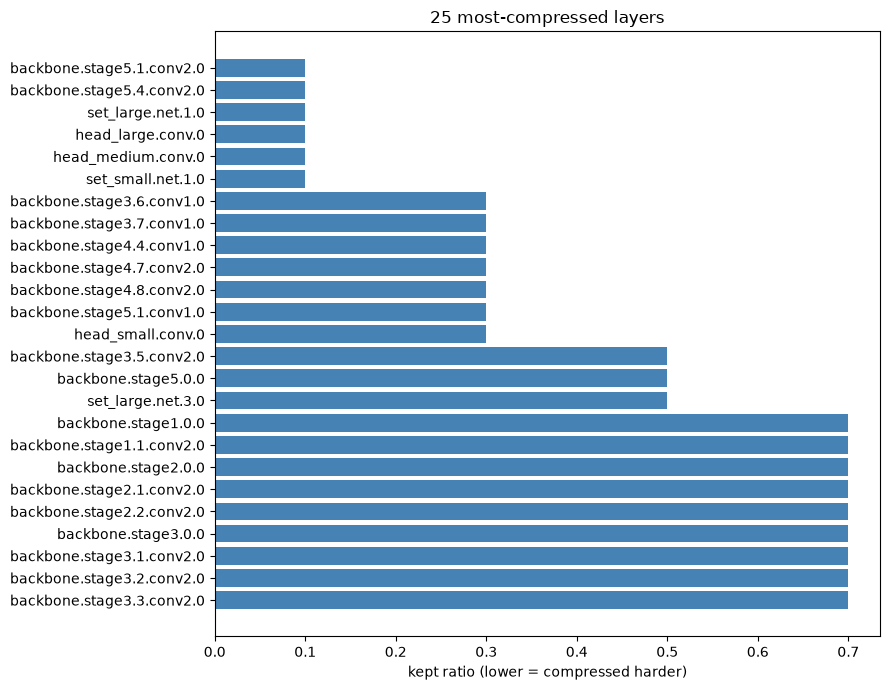

In [22]:
names = [n for n in compression_log if not compression_log[n].get("skipped_no_benefit")]
ratios = [compression_log[n]["chosen_ratio"] for n in names]
order = sorted(range(len(names)), key=lambda i: ratios[i])[:25]

plt.figure(figsize=(9, 7))
plt.barh([names[i] for i in order][::-1], [ratios[i] for i in order][::-1], color="steelblue")
plt.xlabel("kept ratio (lower = compressed harder)")
plt.title("25 most-compressed layers")
plt.tight_layout()
plt.show()

## Summary table

In [23]:
import pandas as pd
summary = pd.DataFrame({
    "metric": ["Total params", "Model size (MB)", "Latency (ms/img)", "mAP@0.5"],
    "original": [f"{p_orig:,}", f"{s_orig:.1f}", f"{lat_orig:.2f}", f"{map_orig:.3f}"],
    "compressed": [f"{p_comp:,}", f"{s_comp:.1f}", f"{lat_comp:.2f}", f"{map_comp:.3f}"],
    "change": [f"{(1-p_comp/p_orig)*100:.1f}%", f"{(1-s_comp/s_orig)*100:.1f}%",
               f"{(1-lat_comp/lat_orig)*100:+.1f}%", f"{(map_comp-map_orig):+.3f}"],
})
summary

,metric,original,compressed,change
0,Total params,"61,545,274","26,408,185",57.1%
1,Model size (MB),235.0,100.9,57.0%
2,Latency (ms/img),6.95,9.81,-41.0%
3,mAP@0.5,0.041,0.040,-0.000


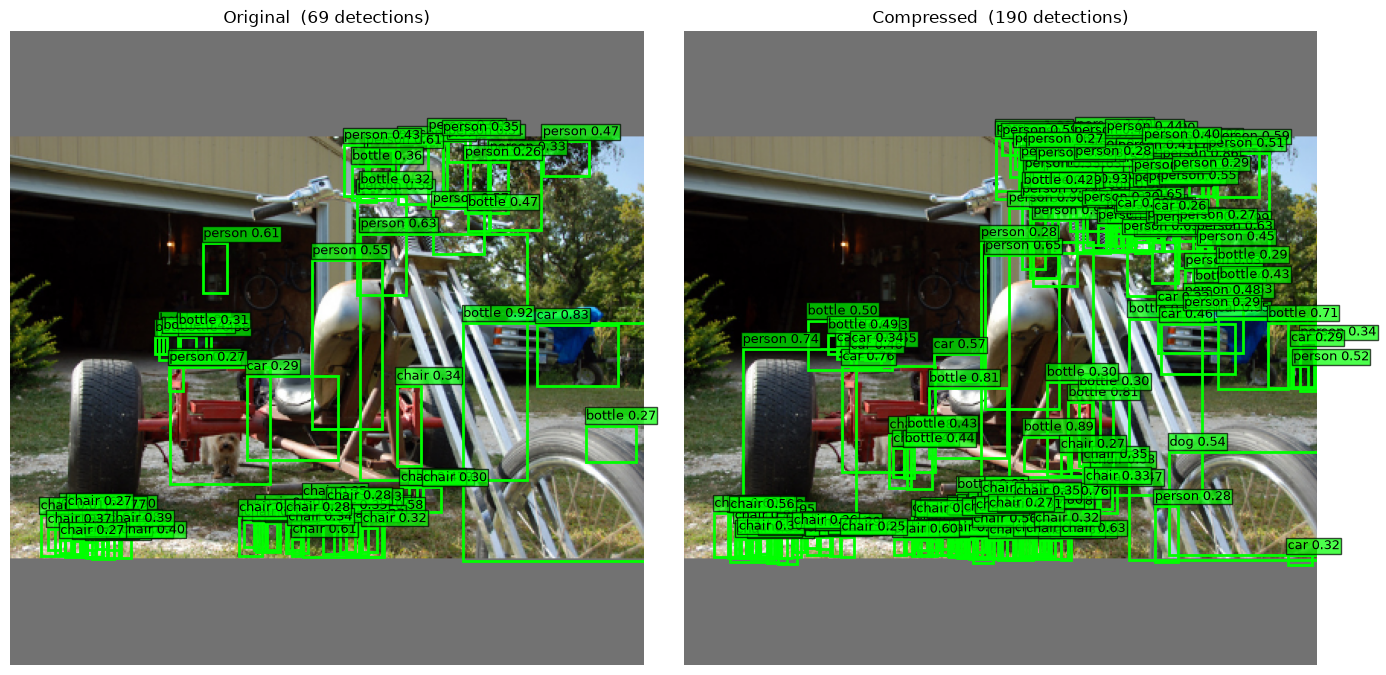

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_detections(ax, img_tensor, boxes, scores, labels, class_names, title):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    ax.imshow(img)
    for box, score, label in zip(boxes, scores, labels):
        x1, y1, x2, y2 = box.tolist()
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  fill=False, edgecolor="lime", linewidth=2)
        ax.add_patch(rect)
        ax.text(x1, max(y1 - 4, 0), f"{class_names[int(label)]} {score:.2f}",
                 color="black", fontsize=9, bbox=dict(facecolor="lime", alpha=0.7, pad=1))
    ax.set_title(f"{title}  ({len(boxes)} detections)")
    ax.axis("off")


# pick one image from the val set (change the index to try others)
img_tensor, _ = val_ds[0]
img_batch = img_tensor.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred_orig = predict_boxes(original, img_batch, NUM_CLASSES, conf_thresh=0.25)[0]
    pred_comp = predict_boxes(compressed, img_batch, NUM_CLASSES, conf_thresh=0.25)[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
draw_detections(axes[0], img_tensor, *pred_orig, CLASS_NAMES, "Original")
draw_detections(axes[1], img_tensor, *pred_comp, CLASS_NAMES, "Compressed")
plt.tight_layout()
plt.show()